# MACHINE LEARNING PROJECT

#### "Disease Prediction System Based On Symptoms"

##### Usman Danial  F2023266622


#### Importing Libraries

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading Dataset
We used `sep=';'` because the dataset is semicolon-separated.

In [49]:
cardio = pd.read_csv("cardio_train.csv", sep=";") #; explains that the data is separated by ;

In [50]:
cardio.head() #prints first 5 rows

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [51]:
cardio.info() #explains the number of rows with the data types of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [52]:
cardio.tail() #prints the last 5 rows

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


In [53]:
cardio.shape #gives the rows x columns

(70000, 13)

In [54]:
cardio.isnull().sum()  #to find out null values

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [55]:
cardio.describe() #gives the quartiles std mean max min values along with total count

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


#### Data Cleaning
In this section, we:
- Convert `age` from days to years.
- Create a new `BMI` column using the formula:  
  **BMI = weight (kg) / height (m)^2**
- Drop irrelevant columns.
- Remove abnormal or extreme values that are likely incorrect.

These steps help make the data more meaningful and useful for model training.


In [56]:
cardio.rename(columns={'ap_hi': 'Systolic_Pressure', 'ap_lo': 'Diastolic_Pressure', 'gluc': 'Glucose', 'alco': 'Alcoholic', 'smoke':'Smoker',}, inplace=True)

#renamed some rows for better understanding

In [57]:
cardio #to view the data set ;)

,id,age,gender,height,weight,Systolic_Pressure,Diastolic_Pressure,cholesterol,Glucose,Smoker,Alcoholic,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


### Understanding the Data

This section explains the meaning of each column in the dataset, including any encoded values:

- **id**: Unique row ID (not useful for prediction).
- **age**: Age of the person in **days** (we'll convert it to years).
- **gender**:
  - 1 = Female
  - 2 = Male
- **height**: Height in centimeters.
- **weight**: Weight in kilograms.
- **ap_hi**: Systolic blood pressure (upper number).
- **ap_lo**: Diastolic blood pressure (lower number).
- **cholesterol**:
  - 1 = Normal
  - 2 = Above normal
  - 3 = Well above normal
- **gluc (glucose levels)**:
  - 1 = Normal
  - 2 = Above normal
  - 3 = Well above normal
- **smoke**:
  - 0 = Non-smoker
  - 1 = Smoker
- **alco**:
  - 0 = Does not consume alcohol
  - 1 = Consumes alcohol
- **active**:
  - 0 = Not physically active
  - 1 = Physically active
- **cardio**: This is the **target column** (what we're predicting):
  - 0 = No cardiovascular disease
  - 1 = Has cardiovascular disease


In [58]:
cardio['age_in_years'] = (cardio['age'] / 365).astype(int) #to convert age into years bcz kon days mein age measure krta hai -_-

In [59]:
cardio

,id,age,gender,height,weight,Systolic_Pressure,Diastolic_Pressure,cholesterol,Glucose,Smoker,Alcoholic,active,cardio,age_in_years
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61


In [60]:
cardio.drop('age', axis=1, inplace=True) #drop age column

In [61]:
cardio

,id,gender,height,weight,Systolic_Pressure,Diastolic_Pressure,cholesterol,Glucose,Smoker,Alcoholic,active,cardio,age_in_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,2,168,76.0,120,80,1,1,1,0,1,0,52
69996,99995,1,158,126.0,140,90,2,2,0,0,1,1,61
69997,99996,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,99998,1,163,72.0,135,80,1,2,0,0,0,1,61


In [62]:
cardio.rename(columns={'cardio': 'Has_Disease'}, inplace=True) #renamed the cardio column bcs the new name makes more sense ;)

In [63]:
cardio

,id,gender,height,weight,Systolic_Pressure,Diastolic_Pressure,cholesterol,Glucose,Smoker,Alcoholic,active,Has_Disease,age_in_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,2,168,76.0,120,80,1,1,1,0,1,0,52
69996,99995,1,158,126.0,140,90,2,2,0,0,1,1,61
69997,99996,2,183,105.0,180,90,3,1,0,1,0,1,52
69998,99998,1,163,72.0,135,80,1,2,0,0,0,1,61


In [64]:
cardio['BMI'] = cardio['weight'] / ((cardio['height'] / 100) ** 2) #to calcuate bmi from weight and height and saved them into the bmi column

In [65]:
cardio

,id,gender,height,weight,Systolic_Pressure,Diastolic_Pressure,cholesterol,Glucose,Smoker,Alcoholic,active,Has_Disease,age_in_years,BMI
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438
69996,99995,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681
69997,99996,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579
69998,99998,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251


In [66]:
cardio['Systolic_Pressure'].describe() #to check for any weird values or outliers

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: Systolic_Pressure, dtype: float64

In [67]:
cardio['Diastolic_Pressure'].describe() #to check for any weird values or outliers

count    70000.000000
mean        96.630414
std        188.472530
min        -70.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      11000.000000
Name: Diastolic_Pressure, dtype: float64

In [68]:
cardio = cardio[(cardio['Systolic_Pressure'] > 80) & (cardio['Systolic_Pressure'] < 250)]
cardio = cardio[(cardio['Diastolic_Pressure'] > 40) & (cardio['Diastolic_Pressure'] < 200)] 
#to remove any weird values or outliers

In [69]:
cardio

,id,gender,height,weight,Systolic_Pressure,Diastolic_Pressure,cholesterol,Glucose,Smoker,Alcoholic,active,Has_Disease,age_in_years,BMI
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438
69996,99995,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681
69997,99996,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579
69998,99998,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251


In [70]:
cardio.isnull().sum() #to check for any null values

id                    0
gender                0
height                0
weight                0
Systolic_Pressure     0
Diastolic_Pressure    0
cholesterol           0
Glucose               0
Smoker                0
Alcoholic             0
active                0
Has_Disease           0
age_in_years          0
BMI                   0
dtype: int64

In [71]:
cardio['height'].describe() #to check for any weird values or outliers

count    68642.000000
mean       164.365432
std          8.182542
min         55.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        250.000000
Name: height, dtype: float64

In [72]:
cardio['weight'].describe() #to check for any weird values or outliers

count    68642.000000
mean        74.134983
std         14.327975
min         11.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64

In [73]:
cardio = cardio[(cardio['height'] > 120) & (cardio['height'] < 220)]
cardio = cardio[(cardio['weight'] > 40) & (cardio['weight'] < 150)]
##to remove any weird values or outliers

In [74]:
cardio['height'].describe()
#to check for any weird values or outliers

count    68407.000000
mean       164.452585
std          7.832014
min        125.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        207.000000
Name: height, dtype: float64

In [75]:
cardio['weight'].describe()
#to check for any weird values or outliers

count    68407.000000
mean        74.094178
std         13.996609
min         41.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        149.000000
Name: weight, dtype: float64

In [76]:
cardio.isnull().sum() #checking for any null values

id                    0
gender                0
height                0
weight                0
Systolic_Pressure     0
Diastolic_Pressure    0
cholesterol           0
Glucose               0
Smoker                0
Alcoholic             0
active                0
Has_Disease           0
age_in_years          0
BMI                   0
dtype: int64

In [77]:
cardio

,id,gender,height,weight,Systolic_Pressure,Diastolic_Pressure,cholesterol,Glucose,Smoker,Alcoholic,active,Has_Disease,age_in_years,BMI
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438
69996,99995,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681
69997,99996,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579
69998,99998,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251


In [78]:
cardio['cholesterol'].value_counts()
#to check how many times each value appears in the data set

cholesterol
1    51297
2     9257
3     7853
Name: count, dtype: int64

In [79]:
cardio['Glucose'].value_counts() #to check how many times each value appears in the data set

Glucose
1    58157
3     5205
2     5045
Name: count, dtype: int64

In [80]:
cardio.duplicated().sum() #to check for any duplicates

np.int64(0)

In [81]:
cardio.dtypes

id                      int64
gender                  int64
height                  int64
weight                float64
Systolic_Pressure       int64
Diastolic_Pressure      int64
cholesterol             int64
Glucose                 int64
Smoker                  int64
Alcoholic               int64
active                  int64
Has_Disease             int64
age_in_years            int64
BMI                   float64
dtype: object

## Data Visualization

Here, we visualize the data to identify patterns and relationships between features and heart disease. We use plots like:

- **Countplots**: to compare counts of people with and without heart disease.
- **Boxplots**: to visualize distributions of age, BMI, and other factors.
- **Heatmaps**: to observe correlations between features.

This step helps us understand the data better before training a machine learning model.

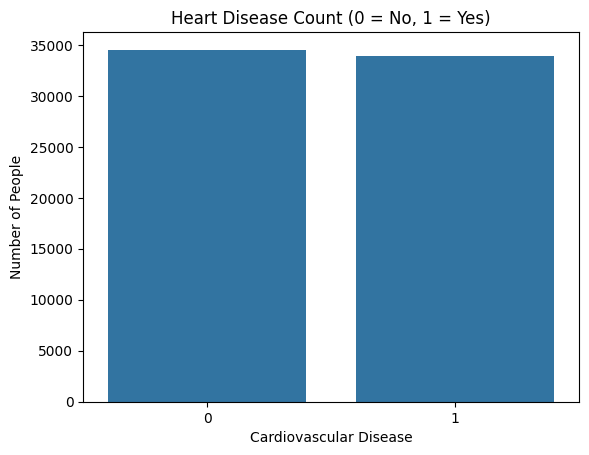

In [82]:
sns.countplot(x='Has_Disease', data=cardio)
plt.title("Heart Disease Count (0 = No, 1 = Yes)")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of People")
plt.show() #bar chart

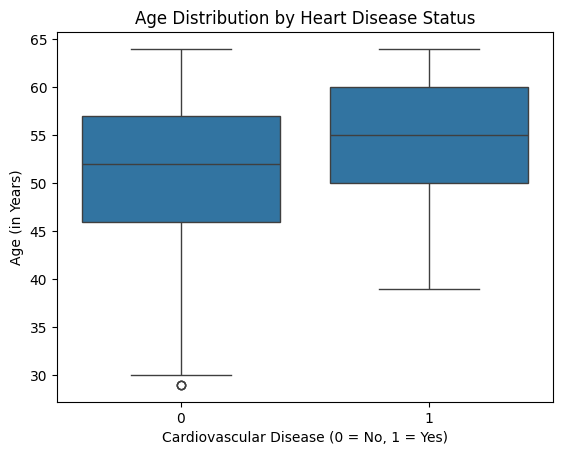

In [83]:
sns.boxplot(x='Has_Disease', y='age_in_years', data=cardio)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Cardiovascular Disease (0 = No, 1 = Yes)")
plt.ylabel("Age (in Years)")
plt.show() #box plot

In [84]:
cardio

,id,gender,height,weight,Systolic_Pressure,Diastolic_Pressure,cholesterol,Glucose,Smoker,Alcoholic,active,Has_Disease,age_in_years,BMI
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438
69996,99995,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681
69997,99996,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579
69998,99998,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251


In [85]:
#defining custom bins and labels
bmi_bins = [0, 18.5, 24.9, 29.9, 34.9, 39.9, float('inf')]
bmi_labels = [0, 1, 2, 3, 4, 5]  # 0 = underweight, 1 = normal, etc.

#applying it to the BMI column
cardio['BMI_category'] = pd.cut(cardio['BMI'], bins=bmi_bins, labels=bmi_labels, right=True).astype(int)


In [86]:
cardio

,id,gender,height,weight,Systolic_Pressure,Diastolic_Pressure,cholesterol,Glucose,Smoker,Alcoholic,active,Has_Disease,age_in_years,BMI,BMI_category
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,1
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,4
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,1
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,2
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438,2
69996,99995,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681,5
69997,99996,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579,3
69998,99998,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251,2


In [87]:
cardio['age_in_years'].value_counts() #to check how many times each value appears in the data set

age_in_years
55    3843
53    3784
57    3584
54    3541
56    3518
59    3497
49    3347
58    3317
51    3289
52    3196
50    3157
60    3133
63    2673
61    2656
62    2150
47    2149
64    2125
45    2043
43    1980
41    1853
48    1778
39    1744
46    1597
40    1585
44    1477
42    1387
29       3
30       1
Name: count, dtype: int64

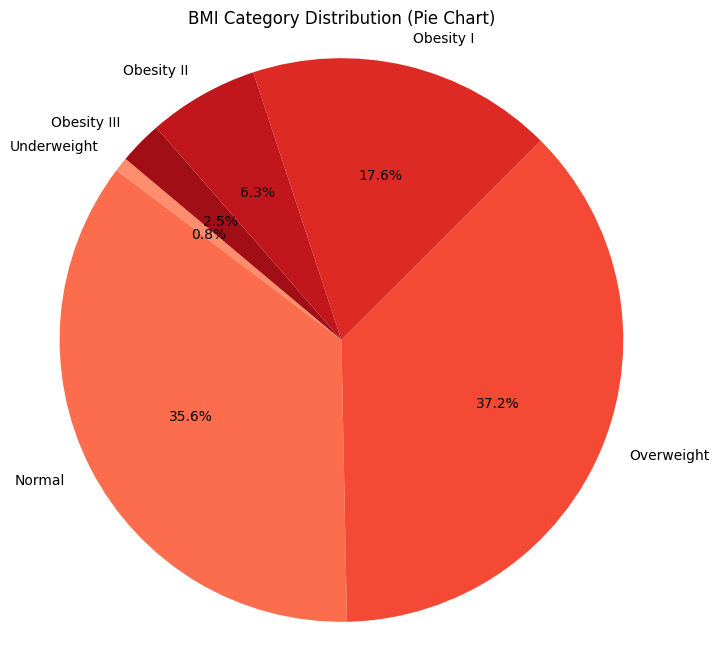

In [88]:
bmi_counts = cardio['BMI_category'].value_counts().sort_index()
labels = ['Underweight', 'Normal', 'Overweight', 'Obesity I', 'Obesity II', 'Obesity III']

plt.figure(figsize=(8, 8))
plt.pie(bmi_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Reds(range(100, 256, 25)))
plt.title("BMI Category Distribution (Pie Chart)")
plt.axis('equal')
plt.show()
#pie chart

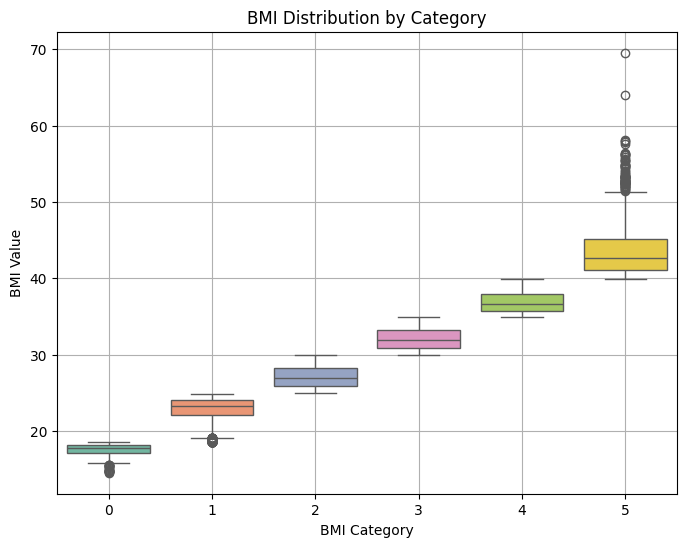

In [89]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='BMI_category', y='BMI', data=cardio, hue='BMI_category', palette='Set2', legend=False)
plt.title("BMI Distribution by Category")
plt.xlabel("BMI Category")
plt.ylabel("BMI Value")
plt.grid(True)
plt.show()

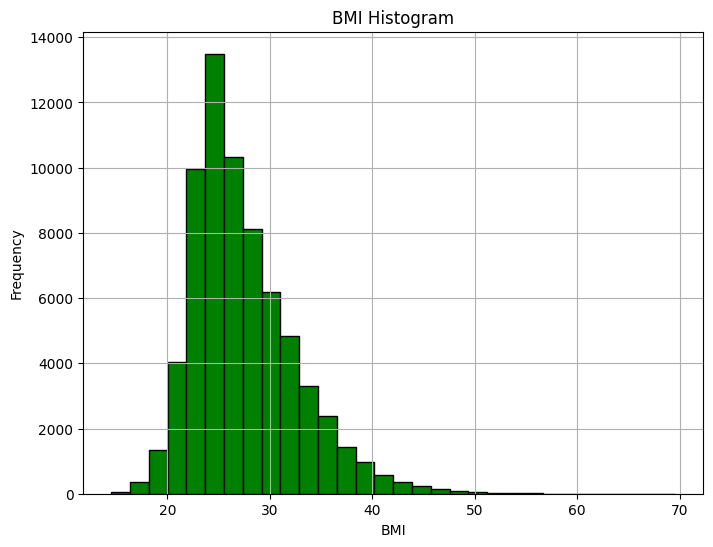

In [90]:
plt.figure(figsize=(8, 6))
plt.hist(cardio['BMI'], bins=30, color='green', edgecolor='black')
plt.title("BMI Histogram")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.grid(True)
plt.show() #histogram

In [91]:
cardio.corr() #for correlation

,id,gender,height,weight,Systolic_Pressure,Diastolic_Pressure,cholesterol,Glucose,Smoker,Alcoholic,active,Has_Disease,age_in_years,BMI,BMI_category
id,1.000000,0.003073,-0.002297,-0.000929,0.001715,-0.000296,0.005634,0.002239,-0.003428,0.000507,0.003992,0.003575,0.003470,-0.000093,0.000423
gender,0.003073,1.000000,0.521309,0.157068,0.061017,0.065426,-0.036848,-0.021707,0.338889,0.170782,0.005888,0.006757,-0.023380,-0.115547,-0.109567
height,-0.002297,0.521309,1.000000,0.308809,0.014701,0.032043,-0.056603,-0.021977,0.196513,0.097861,-0.009394,-0.013920,-0.087468,-0.207041,-0.199332
weight,-0.000929,0.157068,0.308809,1.000000,0.268186,0.249722,0.142930,0.107720,0.068782,0.068651,-0.018685,0.180879,0.057163,0.861936,0.821736
Systolic_Pressure,0.001715,0.061017,0.014701,0.268186,1.000000,0.714096,0.194899,0.093507,0.028068,0.034232,-0.002085,0.426474,0.208889,0.267400,0.256215
Diastolic_Pressure,-0.000296,0.065426,0.032043,0.249722,0.714096,1.000000,0.159930,0.075587,0.024202,0.041830,-0.001388,0.337899,0.153594,0.239516,0.228146
cholesterol,0.005634,-0.036848,-0.056603,0.142930,0.194899,0.159930,1.000000,0.450738,0.010166,0.035402,0.008846,0.221417,0.154991,0.175215,0.171681
Glucose,0.002239,-0.021707,-0.021977,0.107720,0.093507,0.075587,0.450738,1.000000,-0.005802,0.010722,-0.007810,0.089543,0.098761,0.121202,0.115871
Smoker,-0.003428,0.338889,0.196513,0.068782,0.028068,0.024202,0.010166,-0.005802,1.000000,0.340031,0.025240,-0.016147,-0.047948,-0.033786,-0.026125
Alcoholic,0.000507,0.170782,0.097861,0.068651,0.034232,0.041830,0.035402,0.010722,0.340031,1.000000,0.024828,-0.007461,-0.028967,0.018004,0.020725


<function matplotlib.pyplot.show(close=None, block=None)>

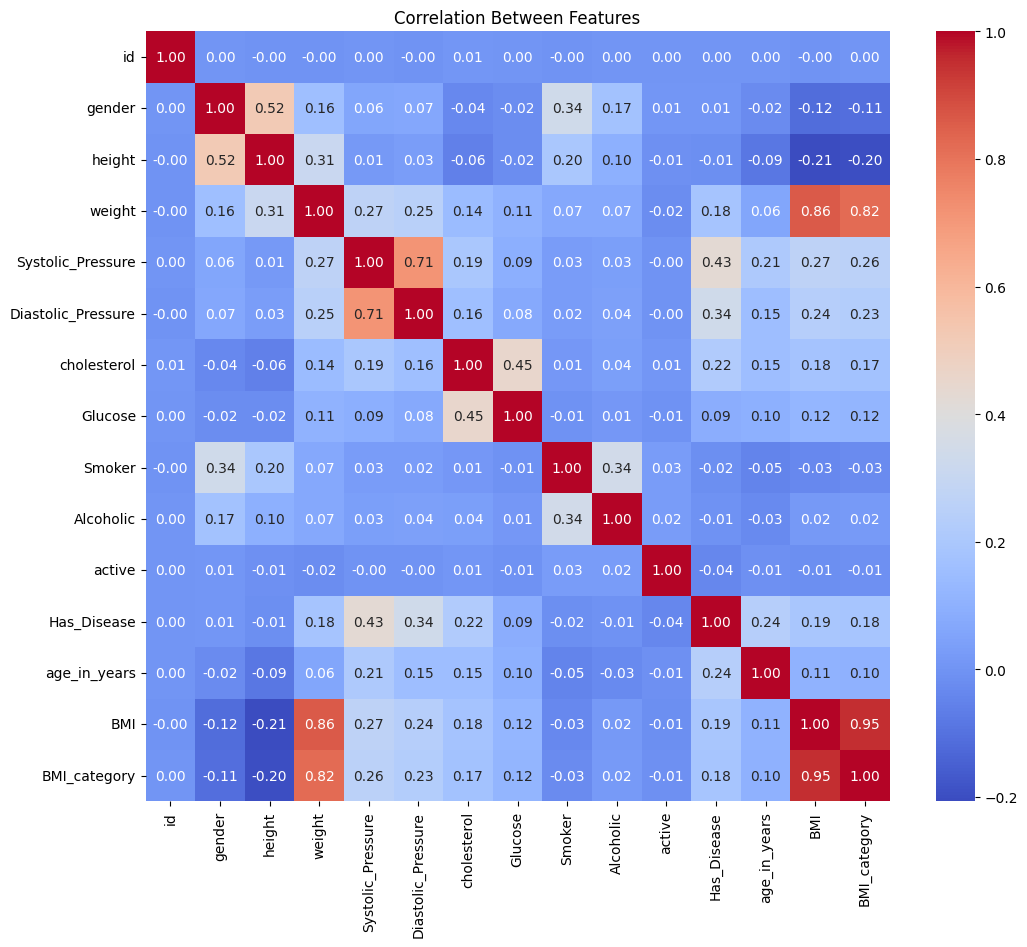

In [92]:
plt.figure(figsize=(12, 10))
sns.heatmap(cardio.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Features")
plt.show 

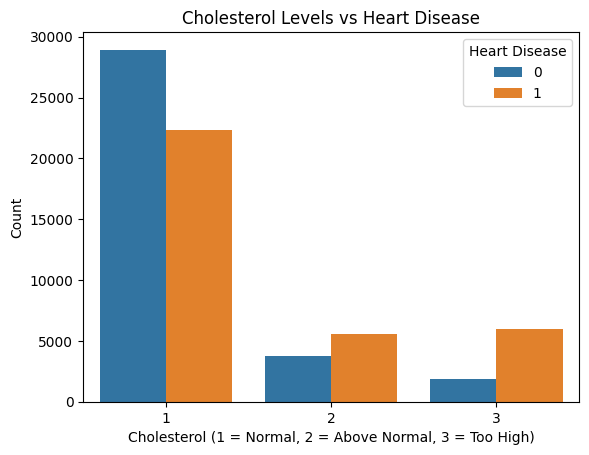

In [93]:
sns.countplot(x='cholesterol', hue='Has_Disease', data=cardio)
plt.title("Cholesterol Levels vs Heart Disease")
plt.xlabel("Cholesterol (1 = Normal, 2 = Above Normal, 3 = Too High)")
plt.ylabel("Count")
plt.legend(title='Heart Disease')
plt.show()

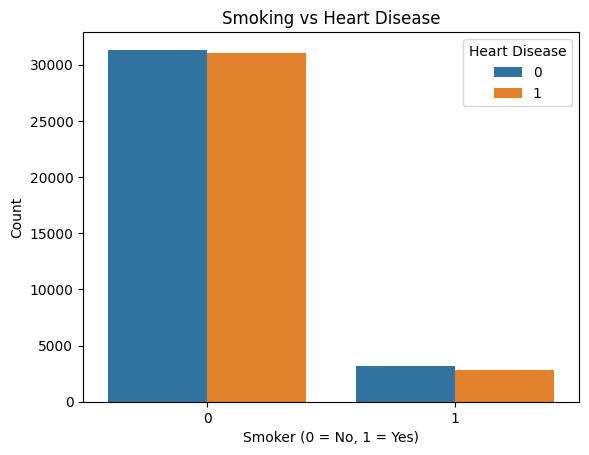

In [94]:
sns.countplot(x='Smoker', hue='Has_Disease', data=cardio)
plt.title("Smoking vs Heart Disease")
plt.xlabel("Smoker (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title='Heart Disease')
plt.show()


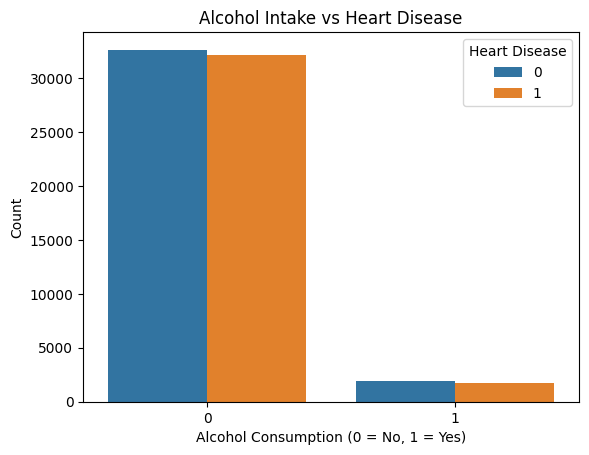

In [95]:
sns.countplot(x='Alcoholic', hue='Has_Disease', data=cardio)
plt.title("Alcohol Intake vs Heart Disease")
plt.xlabel("Alcohol Consumption (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title='Heart Disease')
plt.show()

## Splitting and Scaling the Data

We split the data into training and testing sets:
- **80% training**: used to train the model.
- **20% testing**: used to evaluate how well the model generalizes.

We then **scale** the input features using `StandardScaler` so that all numeric columns have the same scale. This is important for models like logistic regression that are sensitive to feature magnitude.


In [96]:
from sklearn.model_selection import train_test_split

In [97]:
X = cardio.drop('Has_Disease', axis=1) #features (input columns)
y = cardio['Has_Disease'] #target (what we want to predict)

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [99]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Training the Logistic Regression Model

Here, we train a **Logistic Regression** model to classify whether a person has cardiovascular disease.

- The model is trained using the training data only (`X_train`, `y_train`).
- It learns to associate patterns in the features with the output (`cardio`).

We set `max_iter=1000` to allow the model more steps to converge if needed.


In [100]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Making Predictions and Evaluating the Model

After training, we use the **test data** to evaluate how well the model performs on unseen data.

We calculate:
- **Accuracy**: Percentage of correct predictions.
- **Confusion Matrix**: Summary of correct vs incorrect predictions for each class.
- **Classification Report**: Detailed breakdown of precision, recall, and F1-score.

The test data was **never seen by the model during training**, so this gives us a realistic measure of performance.


In [101]:
y_pred = model.predict(X_test_scaled)

In [102]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7258441748282415

Confusion Matrix:
 [[5385 1543]
 [2208 4546]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74      6928
           1       0.75      0.67      0.71      6754

    accuracy                           0.73     13682
   macro avg       0.73      0.73      0.72     13682
weighted avg       0.73      0.73      0.73     13682



## Predicting a New Case

In this step, we provide custom input data (e.g., a new person’s age, blood pressure, BMI, etc.) and use our trained model to predict whether they might have heart disease (0 = No, 1 = Yes).

We apply the same preprocessing (scaling) before prediction to ensure consistency.


In [103]:
person = {
    'id' : 100000,
    'gender': 2,         # Male
    'height': 170,
    'weight': 80,
    'Systolic_Pressure': 140,
    'Diastolic_Pressure': 90,
    'cholesterol': 2,
    'Glucose': 1,
    'Smoker': 0,
    'Alcoholic': 0,
    'active': 1,
    'age_in_years': 52,
    'BMI': 80 / ((170 / 100) ** 2),
    'BMI_category' : 3
}

In [104]:
#convert to DataFrame
person_df = pd.DataFrame([person])

#scale it
person_scaled = scaler.transform(person_df)

#predict
prediction = model.predict(person_scaled)

print("Prediction:", prediction[0])  # 1 = disease, 0 = no disease


Prediction: 1


In [105]:
person1 = {
'id': 200001,
'gender': 2, # Female
'height': 165,
'weight': 55,
'Systolic_Pressure': 115,
'Diastolic_Pressure': 75,
'cholesterol': 1,
'Glucose': 1,
'Smoker': 0,
'Alcoholic': 0,
'active': 1,
'age_in_years': 28,
'BMI': 55 / ((165 / 100) ** 2),
'BMI_category': 1 # Normal
}

In [106]:
#convert to DataFrame
person_df = pd.DataFrame([person1])

#scale it
person_scaled = scaler.transform(person_df)

#predict
prediction = model.predict(person_scaled)

print("Prediction:", prediction[0])  # 1 = disease, 0 = no disease


Prediction: 0
